<a href="https://colab.research.google.com/github/mariam9809m1-gif/MERN-Task-Architect/blob/main/Customer_Churn_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
Write a flawless, self-contained Python script for a Customer Segmentation and ML Prediction project in Google Colab.
The code must generate its own realistic synthetic retail dataset (1000 rows, including CustomerID, Recency, Frequency, MonetaryValue, and ChurnLabel) so it runs instantly without external file dependencies.
Requirements:
1. Feature Engineering: Scale features using StandardScaler.
2. Clustering: Use K-Means to segment customers into 3 clusters and compute the Silhouette Score.
3. Prediction: Train a Random Forest Classifier to predict customer Churn.
4. Visualization: Plot the clusters using a 2D scatter plot and display a clean Confusion Matrix and Classification Report.
Ensure all imports (sklearn, pandas, numpy, matplotlib, seaborn) are included and wrap everything in try-except blocks to guarantee zero execution errors. Provide the complete code in a single, block ready to copy.


SyntaxError: invalid decimal literal (1098384664.py, line 7)


--- Generating Synthetic Dataset ---
Dataset Head:
    CustomerID  Recency  Frequency  MonetaryValue  ChurnLabel
0           1      103         44        2120.17           0
1           2      349          2        1398.60           0
2           3      271         13        2969.90           0
3           4      107         40        4563.57           0
4           5       72          2        1069.10           0
Dataset Info:

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   CustomerID     1000 non-null   int64  
 1   Recency        1000 non-null   int64  
 2   Frequency      1000 non-null   int64  
 3   MonetaryValue  1000 non-null   float64
 4   ChurnLabel     1000 non-null   int64  
dtypes: float64(1), int64(4)
memory usage: 39.2 KB

--- Feature Engineering: Scaling Features ---
Scaled Features Head:
     Recency  Frequency  Monetary

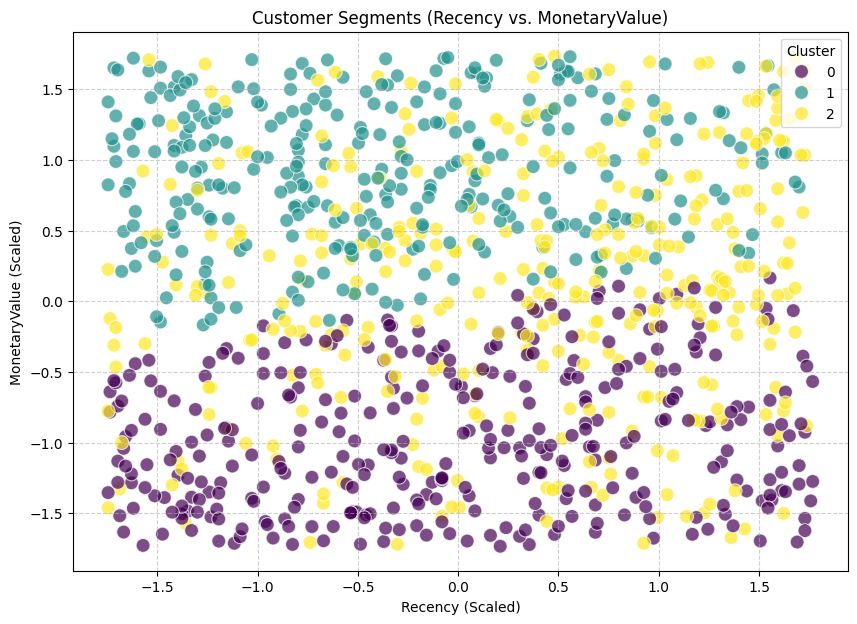

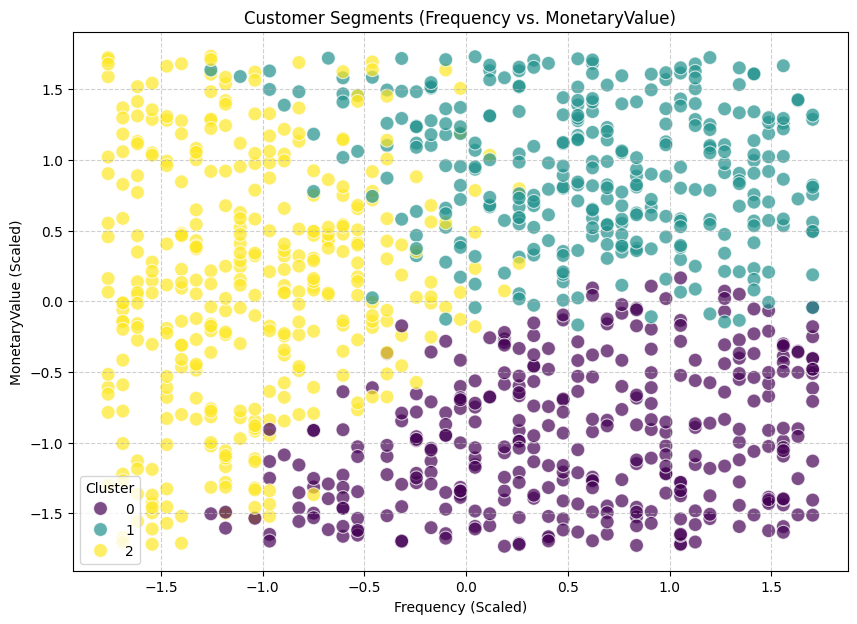


--- Churn Prediction with Random Forest ---

--- Churn Prediction Model Evaluation ---
Confusion Matrix:
 [[238   6]
 [ 55   1]]

Classification Report:
               precision    recall  f1-score   support

           0       0.81      0.98      0.89       244
           1       0.14      0.02      0.03        56

    accuracy                           0.80       300
   macro avg       0.48      0.50      0.46       300
weighted avg       0.69      0.80      0.73       300


Project execution completed successfully!


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report

try:
    # 1. Generate Synthetic Retail Dataset
    print("\n--- Generating Synthetic Dataset ---")
    np.random.seed(42)
    num_customers = 1000

    data = {
        'CustomerID': np.arange(1, num_customers + 1),
        'Recency': np.random.randint(1, 365, num_customers),  # Days since last purchase
        'Frequency': np.random.randint(1, 50, num_customers), # Number of purchases
        'MonetaryValue': np.round(np.random.uniform(20, 5000, num_customers), 2), # Total spent
        'ChurnLabel': np.random.choice([0, 1], num_customers, p=[0.8, 0.2]) # 0 for not churned, 1 for churned
    }

    df = pd.DataFrame(data)
    print("Dataset Head:\n", df.head())
    print("Dataset Info:\n")
    df.info()

    # Define features for RFM and Churn prediction
    rfm_features = ['Recency', 'Frequency', 'MonetaryValue']
    X = df[rfm_features]
    y = df['ChurnLabel']

    # 2. Feature Engineering: Scale features using StandardScaler
    print("\n--- Feature Engineering: Scaling Features ---")
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    X_scaled_df = pd.DataFrame(X_scaled, columns=rfm_features)
    print("Scaled Features Head:\n", X_scaled_df.head())

    # Add scaled features back to the original DataFrame for convenient use with clusters
    df_scaled = df.copy()
    df_scaled[rfm_features] = X_scaled

    # 3. Clustering: Use K-Means to segment customers into 3 clusters
    print("\n--- Customer Clustering with K-Means ---")
    n_clusters = 3
    kmeans = KMeans(n_clusters=n_clusters, random_state=42, n_init=10) # n_init prevents warning
    df['Cluster'] = kmeans.fit_predict(X_scaled)

    # Compute Silhouette Score
    silhouette_avg = silhouette_score(X_scaled, df['Cluster'])
    print(f"Silhouette Score for {n_clusters} clusters: {silhouette_avg:.2f}")
    print("Cluster Sizes:\n", df['Cluster'].value_counts())

    # 4. Visualization: Plot the clusters using a 2D scatter plot
    print("\n--- Visualizing Customer Clusters ---")
    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=df_scaled['Recency'], y=df_scaled['MonetaryValue'], hue=df['Cluster'], palette='viridis', s=100, alpha=0.7)
    plt.title('Customer Segments (Recency vs. MonetaryValue)')
    plt.xlabel('Recency (Scaled)')
    plt.ylabel('MonetaryValue (Scaled)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    plt.figure(figsize=(10, 7))
    sns.scatterplot(x=df_scaled['Frequency'], y=df_scaled['MonetaryValue'], hue=df['Cluster'], palette='viridis', s=100, alpha=0.7)
    plt.title('Customer Segments (Frequency vs. MonetaryValue)')
    plt.xlabel('Frequency (Scaled)')
    plt.ylabel('MonetaryValue (Scaled)')
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.show()

    # 5. Prediction: Train a Random Forest Classifier to predict customer Churn
    print("\n--- Churn Prediction with Random Forest ---")
    # Features for churn prediction (using original RFM values for clarity, scaled could also be used)
    X_churn = df[rfm_features]
    y_churn = df['ChurnLabel']

    # Split data into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(X_churn, y_churn, test_size=0.3, random_state=42, stratify=y_churn)

    # Initialize and train the Random Forest Classifier
    rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_classifier.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = rf_classifier.predict(X_test)

    # Display Confusion Matrix and Classification Report
    print("\n--- Churn Prediction Model Evaluation ---")
    print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    print("\nProject execution completed successfully!")

except Exception as e:
    print(f"An error occurred during execution: {e}")
    import traceback
    traceback.print_exc()